# Comparing centers.csv and numpy grid methods
### To run these codes, activate the tf_env

In [33]:
# import pandas as pd
# import numpy as np
# import tensorflow as tf

# grid = pd.read_csv("/home/shilaj/repitframework/repitframework/Assets/natural_convection/centres.csv", header=None)
# t_data = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy")

# grid = grid.drop(0, axis=0).astype(np.float32)
# grid_tf = tf.reshape(grid, shape=[-1,4])
# grid_np = grid_tf.numpy()
# ngrid_xnp = np.array(200*grid_np[:,1:2]+0.51, dtype=np.int64)
# ngrid_ynp = np.array(200*grid_np[:,2:3]+0.51, dtype=np.int64)

In [34]:
# t_matrix = np.ones([200,200])
# for i in range(0, 40000):
#     ngrid_x = ngrid_xnp[i]
#     ngrid_y = ngrid_ynp[i]
#     t_matrix[ngrid_x-1,ngrid_y-1] = t_data[i]

In [35]:
# t_matrix_np = t_data.reshape(200,200, order='F')

## Below comparison shows that; to conform it with professor's code we have to order it in F-major order

In [36]:
# np.allclose(t_matrix, t_matrix_np)


True

# Comparing professor's method and my method for feature selection:

In [58]:
import numpy as np
from pathlib import Path
import json
import Ofpp
import re
from repitframework import OpenFOAM

In [59]:
data = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
ux = data[:, 0].reshape(200,200, order="F")
uy = data[:, 1].reshape(200,200, order="F")

In [60]:
# Professors method: 
ux_pad = np.pad(ux, ((1,1), (1,1)), mode="constant", constant_values=0)
prof_method_ux = np.zeros([39204, 5])
k = 0
for i in range(2,200):
	for j in range(2,200):
		prof_method_ux[k,0] = ux_pad[i,j]
		prof_method_ux[k,1] = ux_pad[i-1,j]
		prof_method_ux[k,2] = ux_pad[i+1,j]
		prof_method_ux[k,3] = ux_pad[i,j-1]
		prof_method_ux[k,4] = ux_pad[i,j+1]
		k += 1

In [61]:
# My method:
window_shape = (3, 3)
sliding_window = np.lib.stride_tricks.sliding_window_view(ux, window_shape)
x,y = 1,1
correlated_features = np.stack([
	sliding_window[:,:,x,y],
	sliding_window[:,:,x-1,y],
	sliding_window[:,:,x+1,y],
	sliding_window[:,:,x,y-1],
	sliding_window[:,:,x,y+1]
],axis=-1).reshape(-1,5)

In [65]:
ux

array([[-0.0119128 , -0.00999168, -0.00788239, ...,  0.0246806 ,
         0.0189697 , -0.00594518],
       [-0.0169824 , -0.0160015 , -0.0133442 , ...,  0.066698  ,
         0.0629324 ,  0.0460888 ],
       [-0.0148263 , -0.0170253 , -0.0158739 , ...,  0.112206  ,
         0.112176  ,  0.0991994 ],
       ...,
       [-0.0110955 , -0.0269181 , -0.0382983 , ...,  0.012997  ,
         0.0128753 ,  0.00976527],
       [ 0.0135006 , -0.00434889, -0.0176506 , ...,  0.00971267,
         0.0108962 ,  0.0101799 ],
       [ 0.0108766 ,  0.0096557 ,  0.00640758, ...,  0.00424294,
         0.00531634,  0.00598413]])

In [63]:
prof_method_ux

array([[-0.0160015 , -0.00999168, -0.0170253 , -0.0169824 , -0.0133442 ],
       [-0.0133442 , -0.00788239, -0.0158739 , -0.0160015 , -0.0115032 ],
       [-0.0115032 , -0.00639967, -0.0144757 , -0.0133442 , -0.0101853 ],
       ...,
       [ 0.00876966,  0.0125816 ,  0.00346555,  0.00805921,  0.00971267],
       [ 0.00971267,  0.012997  ,  0.00424294,  0.00876966,  0.0108962 ],
       [ 0.0108962 ,  0.0128753 ,  0.00531634,  0.00971267,  0.0101799 ]])

In [64]:
correlated_features

array([[-0.0160015 , -0.00999168, -0.0170253 , -0.0169824 , -0.0133442 ],
       [-0.0133442 , -0.00788239, -0.0158739 , -0.0160015 , -0.0115032 ],
       [-0.0115032 , -0.00639967, -0.0144757 , -0.0133442 , -0.0101853 ],
       ...,
       [ 0.00876966,  0.0125816 ,  0.00346555,  0.00805921,  0.00971267],
       [ 0.00971267,  0.012997  ,  0.00424294,  0.00876966,  0.0108962 ],
       [ 0.0108962 ,  0.0128753 ,  0.00531634,  0.00971267,  0.0101799 ]])

In [62]:
np.allclose(prof_method_ux, correlated_features)

True

# Comparing normalization and denormalization using numpy and pandas

In [29]:
import numpy as np
import pandas as pd

In [28]:
ml_dataset = np.random.rand(39204*2, 18)
dataset = ml_dataset[:,3:18]
train_labels = ml_dataset[:,0:3]

In [38]:
# Normalize the dataset using pandas:
dataset_df = pd.DataFrame(dataset)
train_stats = dataset_df.describe().transpose()

labels_df = pd.DataFrame(train_labels)
labels_stats = labels_df.describe().transpose()

In [40]:
normed_dataset = (dataset_df - train_stats['mean']) / train_stats['std']
normed_labels = (labels_df - labels_stats['mean']) / labels_stats['std']
unnormed_labels = (normed_labels * labels_stats['std']) + labels_stats['mean']

In [41]:
# Normalize the dataset using numpy:
mean_train = np.mean(dataset, axis=0)
std_train  = np.std(dataset, axis=0)

mean_labels = np.mean(train_labels, axis=0)
std_labels = np.std(train_labels, axis=0)

normed_dataset_np = (dataset - mean_train) / std_train
normed_labels_np = (train_labels - mean_labels) / std_labels
unnormed_labels_np = (normed_labels_np * std_labels) + mean_labels

In [47]:
np.allclose(normed_dataset, normed_dataset_np)

True

In [48]:
np.allclose(normed_labels, normed_labels_np)

True

In [51]:
np.allclose(unnormed_labels, unnormed_labels_np)

True

In [53]:
np.allclose(unnormed_labels, train_labels)

True

# Comparing difference calculation using framework and numpy

In [1]:
import numpy as np

from repitframework.OpenFOAM.utils import OpenfoamUtils
from repitframework.config import TrainingConfig
from repitframework.Dataset.fvmn import FVMNDataset

In [2]:
training_config = TrainingConfig()
fvmn_dataset = FVMNDataset(training_config)
t_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.02.npy")
t_1003 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.03.npy")
u_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
u_1003 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.03.npy")

In [3]:
input_data = fvmn_dataset._prepare_input(10.02)

In [13]:
t_framework_internal = input_data[:,::5][:,2:]

In [14]:
t_1002_internal = t_1002.reshape(200,200, order='F')[1:-1,1:-1].reshape(-1,1, order='F')

In [15]:
np.allclose(t_framework_internal, t_1002_internal)

True

In [16]:
# Load T value for time step 10.02 and 10.03:
t_now = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy").reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
t_next = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.02.npy").reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
u_now = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
ux_now = u_now[:,0].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
uy_now = u_now[:,1].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
U_next = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
ux_next = U_next[:,0].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
uy_next = U_next[:,1].reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")

data_now = np.concatenate([ux_now,uy_now, t_now], axis=1)
data_next = np.concatenate([ux_next, uy_next, t_next], axis=1)
data_diff_np = data_next - data_now

In [17]:
data_diff_framework = fvmn_dataset._calculate_difference(time=10.01)

In [20]:
np.allclose(data_diff_np, data_diff_framework)

True

# Run the prediction (Using professor's way trained network)

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def make_mlp(input_dim=15, hidden_dim=512, num_hidden_layers=11, output_dim=1):
	# In Keras code: 
	# - input_shape=(15,) 
	# - 11 layers of Dense(512, relu)
	# - 1 layer of Dense(1)
	layers = []
	layers.append(nn.Linear(input_dim, hidden_dim))
	layers.append(nn.ReLU())
	for _ in range(num_hidden_layers - 1):
		layers.append(nn.Linear(hidden_dim, hidden_dim))
		layers.append(nn.ReLU())
	layers.append(nn.Linear(hidden_dim, output_dim))
	return nn.Sequential(*layers)

# Define the networks from the snippet
class NetA(nn.Module):
	def __init__(self):
		super(NetA, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetP(nn.Module):
	def __init__(self):
		super(NetP, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetPH(nn.Module):
	def __init__(self):
		super(NetPH, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetU(nn.Module):
	def __init__(self):
		super(NetU, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

class NetV(nn.Module):
	def __init__(self):
		super(NetV, self).__init__()
		self.model = make_mlp(input_dim=15)
	def forward(self, x):
		return self.model(x)

# The PyTorch equivalent of FVMN model that holds multiple subnetworks
class FVMN(nn.Module):
	def __init__(self, use_p=False, use_ph=False):
		super(FVMN, self).__init__()
		self.net_a = NetA()
		self.net_u = NetU()
		self.net_v = NetV()
		# If you want to use net_p or net_ph:
		self.use_p = use_p
		self.use_ph = use_ph
		if self.use_p:
			self.net_p = NetP()
		if self.use_ph:
			self.net_ph = NetPH()

	def forward(self, x):
		# x should be shape [batch, 15] for these subnets
		pred_a = self.net_a(x)
		pred_u = self.net_u(x)
		pred_v = self.net_v(x)
		
		# If needed:
		if self.use_p:
			pred_p = self.net_p(x)
		else:
			pred_p = None
		
		if self.use_ph:
			pred_ph = self.net_ph(x)
		else:
			pred_ph = None

		# Return predictions as a dict or tuple
		# Keras code references these predictions separately. 
		# Let's return as a dictionary for clarity:
		return {
			'a': pred_a, 
			'u': pred_u, 
			'v': pred_v
		}


In [27]:
from repitframework.Models.FVMN.fvmn import FVMNetwork
from repitframework.config import TrainingConfig, OpenfoamConfig
from repitframework.Dataset.fvmn import FVMNDataset
from runner import Trainer, get_dataloader

In [31]:
training_config = TrainingConfig()
model = FVMNetwork(training_config)
# trainer = Trainer(training_config,model, training_config.optimizer,
# 				  training_config.loss, model_name="pt_checkpoint.pth")

In [4]:
trainer.predict()

10.03

In [12]:
import json
predicted_output = np.load("/home/shilaj/repitframework/denormed_data_1003.npy")
combined_output = np.load("/home/shilaj/repitframework/data_1003.npy")
prev_output = combined_output - predicted_output

with open("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/denorm_metrics.json", "r") as f:
	metrics = json.load(f)
	
predicted_output = (predicted_output * metrics["label_STD"]) + metrics["label_MEAN"]
predicted_output = predicted_output + prev_output
predicted_output_t = np.flipud(predicted_output[:,0].reshape(198,198, order="F"))
predicted_output_ux = np.flipud(predicted_output[:,1].reshape(198,198, order="F"))
predicted_output_uy = np.flipud(predicted_output[:,2].reshape(198,198, order="F"))

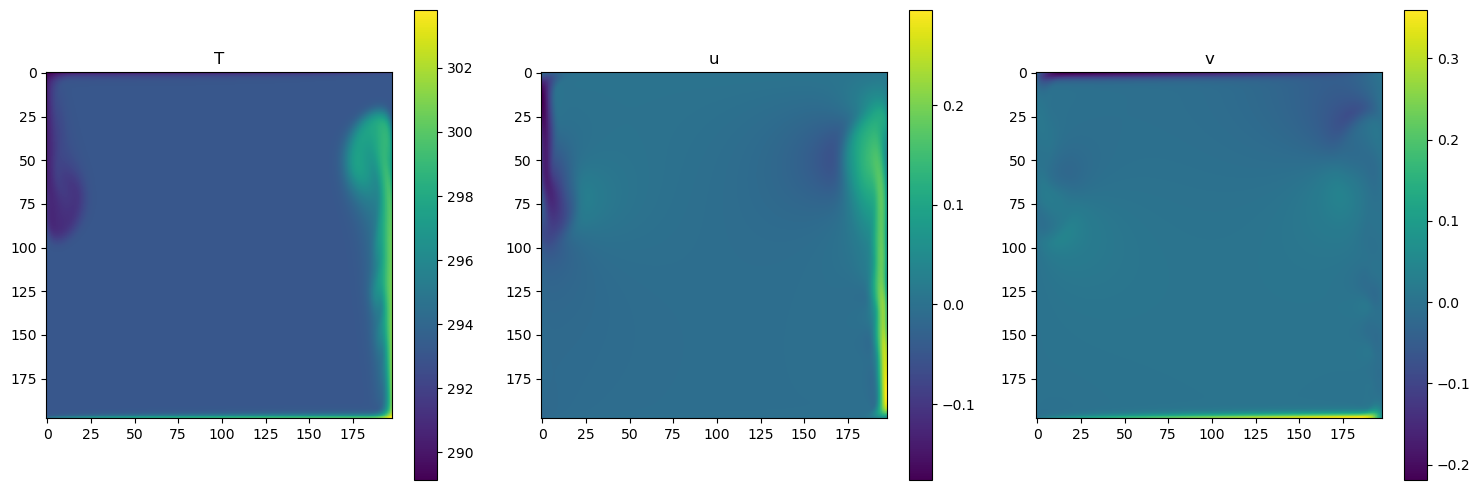

In [13]:
# Visualize the results
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(predicted_output_t)
ax[0].set_title('T')
fig.colorbar(ax[0].imshow(predicted_output_t))
ax[1].imshow(predicted_output_ux)
ax[1].set_title('u')
fig.colorbar(ax[1].imshow(predicted_output_ux))
ax[2].imshow(predicted_output_uy)
ax[2].set_title('v')
fig.colorbar(ax[2].imshow(predicted_output_uy))
plt.tight_layout()

# Comparing professor's data sample and mine

In [1]:
import pandas as pd
import numpy as np

prof_data_1001 = pd.read_csv("/home/shilaj/shilaj_data/repit_code/DataSample/traindata10.01.csv")
prof_t = prof_data_1001["T"].values
prof_ux = prof_data_1001["Ux"].values
prof_uy = prof_data_1001["Uy"].values

my_t = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.01.npy")
my_u = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.01.npy")
my_ux = my_u[:,0]
my_uy = my_u[:,1]



# Load professor's ways trained model

In [19]:
import torch

model_dict = torch.load("/home/shilaj/shilaj_data/repit_code/pt_checkpoint.pth", weights_only=True)
model = model_dict["model_state_dict"]

model_test = torch.load("/home/shilaj/repitframework/repitframework/ModelDump/natural_convection/best_model.pth", weights_only=True)

In [32]:
model.load_state_dict(model_test)

<All keys matched successfully>

In [33]:
model.parameters()

<generator object Module.parameters at 0x74deb5f31d20>

In [41]:
a = np.random.rand(1000,3)
a[:,0:1].shape

(1000, 1)

In [2]:
from repitframework.plot_utils import visualize_output
from repitframework.config import BaseConfig

base_config = BaseConfig()
visualize_output(base_config=base_config, 
				 timestamp=12.4,
				 is_ground_truth=False,
				 save_name="predicted")

/home/shilaj/repitframework/repitframework/plot_utils.py:57: UserWarning: 

Data dimension mismatch: 
	Variable shape: (40000, 1)
	Expected data dimension: 2
Please update the data_dim parameter in the config file if you want to visualize all the dimensions of the data.

  warnings.warn(warning_string.format(shape_of_variable, data_dim))


True

In [3]:
from datetime import datetime

start_time = datetime.strptime("15:22:12", "%H:%M:%S")
end_time = datetime.strptime("16:34:20", "%H:%M:%S")


# Visualizing things

# Visualizing outputs

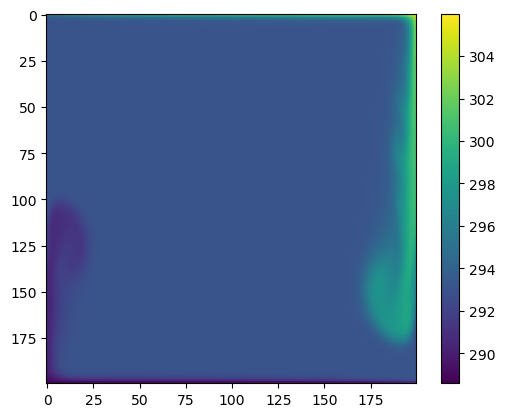

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

my_t = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/T_10.1.npy")
my_t = my_t.reshape(200,200, order="F")

plt.imshow(my_t)
plt.colorbar()

In [83]:
a = np.random.rand(100, 15)
a[:, ::5]

array([[7.34022101e-01, 8.44237706e-02, 7.61359935e-02],
       [7.61632706e-01, 4.45631494e-01, 1.51761946e-01],
       [2.94432095e-01, 4.46502733e-03, 4.58997292e-01],
       [2.15930830e-02, 8.90331404e-01, 5.15439586e-01],
       [1.13290925e-01, 7.93133131e-01, 1.05006822e-01],
       [9.60197194e-01, 1.72144064e-01, 2.64578039e-01],
       [5.37358914e-01, 3.98268344e-01, 7.48202577e-01],
       [8.93366940e-01, 7.87414574e-01, 2.60271398e-01],
       [2.17998408e-01, 2.12967173e-01, 6.76129080e-01],
       [9.83370251e-01, 3.83301723e-01, 9.31458534e-01],
       [9.70504388e-01, 6.73337452e-01, 4.61314844e-01],
       [6.90561870e-01, 8.00266638e-01, 2.49392265e-01],
       [7.35198757e-01, 7.79045847e-01, 6.49633453e-01],
       [8.68415842e-01, 2.15848431e-01, 2.06632700e-01],
       [5.54608666e-01, 1.35719928e-01, 8.32448178e-01],
       [1.85081266e-01, 7.29519118e-01, 8.26998947e-01],
       [8.57724921e-01, 9.95209134e-01, 5.41678378e-01],
       [4.42344283e-01, 8.97047

In [91]:
a[:, 5].shape

(100,)

In [46]:
time_list_1 = np.arange(10.49,10.52,0.01)
time_list_2 = np.arange(10.01,10.05,0.01)

In [61]:
num_points = np.ceil((10.02 - 10.0)/0.01) + 1
time_list = np.round(np.linspace(10.0, 10.02, int(num_points)),2)

In [63]:
time_list

array([10.  , 10.01, 10.02])

# Visualizing Relative Residual Mass

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
with open("/home/shilaj/shilaj_data/repitframework/repitframework/ModelDump/natural_convection/prediction_metrics.json", "r") as f:
	metrics = json.load(f)

# x_ticks = [10.03]
# for i in range(len(first_running_time)):
#     if first_relative_residual[i] >= 5.0:
#         x_ticks.append(first_running_time[i+1])

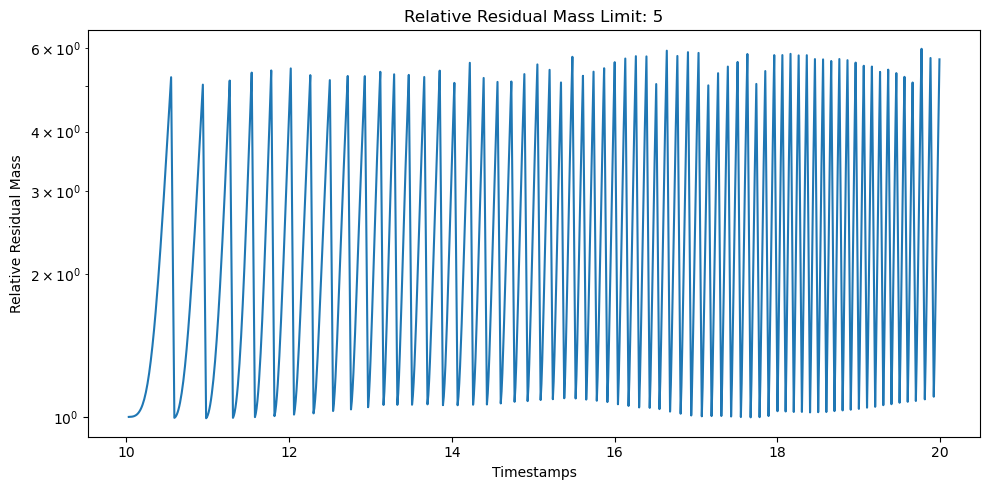

In [4]:
running_times = metrics["Running Time"]

relative_residual = metrics["Relative Residual Mass"]

plt.figure(figsize=(10,5))
plt.plot(running_times, relative_residual)
# plt.xticks(x_ticks)
plt.xlabel("Timestamps")
plt.yscale("log")
plt.ylabel("Relative Residual Mass")
plt.title("Relative Residual Mass Limit: 5")
plt.tight_layout()
plt.savefig("/home/shilaj/shilaj_data/repitframework/repitframework/ModelDump/natural_convection/relative_residual_3GT.png")

In [63]:
np.random.seed(42)
t_51_predicted = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.51_predicted.npy").reshape(200,200, order="F")
u_1001 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.51_predicted.npy")
ux_51_predicted = u_1001[:,0].reshape(200,200, order="F")
uy_51_predicted = u_1001[:,1].reshape(200,200, order="F")

t_51 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_10.51.npy").reshape(200,200, order="F")
u_1002 = np.load("/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_10.51.npy")
ux_51 = u_1002[:,0].reshape(200,200, order="F")
uy_51 = u_1002[:,1].reshape(200,200, order="F")

ground_truth = [t_51, ux_51, uy_51]
difference = [t_51_predicted - t_51, ux_51_predicted - ux_51, uy_51_predicted - uy_51]

# Checking Residual Values for Predicted-CFD and Ground-Truth CFD

In [13]:
import Ofpp
import numpy as np
import matplotlib.pyplot as plt
from repitframework.Metrics.ResidualNaturalConvection import residual_mass
import imageio

In [14]:
residual_ground_truth = []
residual_predicted = []

In [3]:
def plot_difference(timestamp):
	framework_t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection/T_{timestamp}.npy").reshape(200,200, order="F")
	ground_truth_t = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_backup/T_{timestamp}.npy").reshape(200,200, order="F")

	framework_u = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection/U_{timestamp}.npy")
	ground_truth_u = np.load(f"/home/shilaj/repitframework/repitframework/Assets/natural_convection_backup/U_{timestamp}.npy")
	framework_ux = framework_u[:,0].reshape(200,200, order="F")
	framework_uy = framework_u[:,1].reshape(200,200, order="F")
	ground_truth_ux = ground_truth_u[:,0].reshape(200,200, order="F")
	ground_truth_uy = ground_truth_u[:,1].reshape(200,200, order="F")

	residual_ground_truth.append(residual_mass(ground_truth_ux, ground_truth_uy))
	residual_predicted.append(residual_mass(framework_ux, framework_uy))

	fig, ax = plt.subplots(2,2, figsize=(10,15))
	fig.suptitle(f"Comparison between Ground truth and Framework results: {timestamp}")

	ax[0,0].imshow(framework_uy)
	ax[0,0].set_title("Framework Ground Truth Uy")
	plt.colorbar(ax[0,0].imshow(framework_uy))
	ax[0,1].imshow(framework_ux)
	ax[0,1].set_title("Framework Ground Truth Ux")
	plt.colorbar(ax[0,1].imshow(framework_ux))
	ax[0,2].imshow(framework_t)
	ax[0,2].set_title("Framework Ground Truth T")
	plt.colorbar(ax[0,2].imshow(framework_t))

	ax[1,0].imshow(ground_truth_uy)
	ax[1,0].set_title("Ground Truth Uy")
	plt.colorbar(ax[1,0].imshow(ground_truth_uy))
	ax[1,1].imshow(ground_truth_ux)
	ax[1,1].set_title("Ground Truth Ux")
	plt.colorbar(ax[1,1].imshow(ground_truth_ux))
	ax[1,2].imshow(ground_truth_t)
	ax[1,2].set_title("Ground Truth T")
	plt.colorbar(ax[1,2].imshow(ground_truth_t))

	# ax[2,0].imshow(framework_uy - ground_truth_uy)
	# ax[2,0].set_title("Difference Uy")
	# plt.colorbar(ax[2,0].imshow(framework_uy - ground_truth_uy))
	# ax[2,1].imshow(framework_ux - ground_truth_ux)
	# ax[2,1].set_title("Difference Ux")
	# plt.colorbar(ax[2,1].imshow(framework_ux - ground_truth_ux))
	# ax[2,2].imshow(framework_t - ground_truth_t)
	# ax[2,2].set_title("Difference T")
	# plt.colorbar(ax[2,2].imshow(framework_t - ground_truth_t))
	# plt.tight_layout()

	fig.canvas.draw()
	rgb_array = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(fig.canvas.get_width_height()[::-1] + (4,))
	plt.close()
	return rgb_array


def generate_time(start_time, end_time, step):
	timestamps = []
	while start_time <= end_time:
		start_time = round(start_time, 2)
		timestamps.append(start_time)
		start_time += step
	return timestamps


In [4]:
images_list = []
time_list = generate_time(10.51, 20.0, 0.01)
for time in time_list:
	images_list.append(plot_difference(time))

imageio.mimsave("/home/shilaj/repitframework/repitframework/difference_animation_step_3.gif", images_list, fps=50)

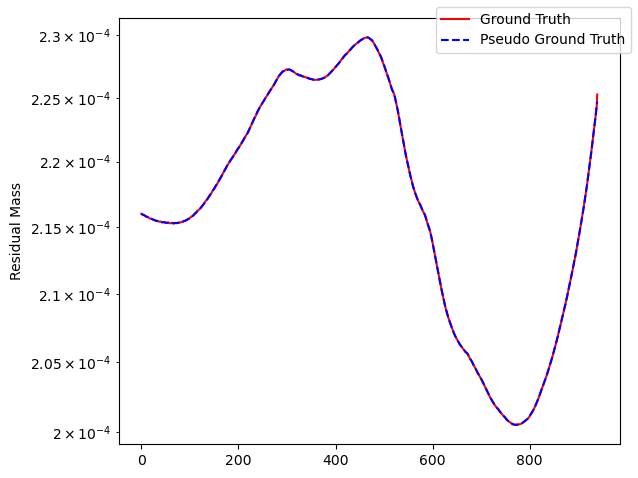

In [8]:
fig, ax = plt.subplots()

ax.plot(residual_ground_truth[10:], label="Ground Truth", color="red", linestyle="-")
ax.plot(residual_predicted[10:], label="Pseudo Ground Truth", color="blue", linestyle="--")
ax.set_ylabel("Residual Mass")
fig.legend()
ax.set_yscale("log")
fig.tight_layout()
fig.savefig("/home/shilaj/repitframework/repitframework/residual_mass_comparison_step_3_After10thTimeStep.png")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t_1001 = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/T_10.03.npy")
u_1001 = np.load("/home/shilaj/shilaj_data/repitframework/repitframework/Assets/natural_convection/U_10.02.npy")
t_1001 = t_1001.reshape(200,200, order="F")[1:-1,1:-1].reshape(-1,1, order="F")
u_1001 = u_1001.reshape(200,200,3, order="F")[1:-1,1:-1,:].reshape(-1,3, order="F")


In [7]:
t_avg = np.mean(t_1001)

# Dissecting Ofpp library

In [14]:
file_path = "/home/shilaj/shilaj_data/repitframework/repitframework/Solvers/natural_convection/10.01/phi"

with open(file_path, "r") as f:
    content = f.readlines()
    
content

['/*--------------------------------*- C++ -*----------------------------------*\\\n',
 '  =========                 |\n',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox\n',
 '   \\\\    /   O peration     | Website:  https://openfoam.org\n',
 '    \\\\  /    A nd           | Version:  12\n',
 '     \\\\/     M anipulation  |\n',
 '\\*---------------------------------------------------------------------------*/\n',
 'FoamFile\n',
 '{\n',
 '    format      ascii;\n',
 '    class       surfaceScalarField;\n',
 '    location    "10.01";\n',
 '    object      phi;\n',
 '}\n',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //\n',
 '\n',
 'dimensions      [1 0 -1 0 0 0 0];\n',
 '\n',
 'internalField   nonuniform List<scalar> \n',
 '79600\n',
 '(\n',
 '-9.07055498999e-06\n',
 '9.07025804464e-06\n',
 '-9.60743292583e-06\n',
 '5.36614627241e-07\n',
 '-7.90299560801e-06\n',
 '-1.70469491245e-06\n',
 '-6.20630407788e-06\n',
 '-1.69694135925

In [2]:
import Ofpp

case_directory = "/home/shilaj/shilaj_data/repitframework/repitframework/Solvers/natural_convection"

mesh = Ofpp.mesh_parser.FoamMesh(case_directory)